## Работа Максимовой Алины 6133-010402D
Импортируем необходимые библиотеки:

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
from numba import cuda
import pandas as pd

Реализация для CPU:

In [14]:
def preprocess_cpu(substrings):
    char_map = [[] for _ in range(256)]
    for idx, s in enumerate(substrings):
        for pos, ch in enumerate(s):
            char_map[ch].append((idx, pos))
    return char_map

def mass_search_CPU(H, substrings, return_positions=True):
    n_sub = 0
    for _ in substrings: n_sub += 1

    h = 0
    for _ in H: h += 1

    R = []
    for s in substrings:
        s_len = 0
        for _ in s: s_len += 1

        row = []
        j = 0
        while j < h:
            row = row + [s_len]
            j = j + 1
        R = R + [row]

    char_map = preprocess_cpu(substrings)

    curr_h_idx = 0
    for ch in H:
        for item in char_map[ch]:
            idx_sub = item[0]
            pos = item[1]
            col = curr_h_idx - pos
            if col >= 0:
                R[idx_sub][col] = R[idx_sub][col] - 1
        curr_h_idx = curr_h_idx + 1

    found_positions = []
    found_any = [False] * n_sub

    i = 0
    while i < n_sub:
        j = 0
        while j < h:
            if R[i][j] == 0:
                found_positions = found_positions + [(i, j)]
                found_any[i] = True
            j = j + 1
        i = i + 1

    if return_positions:
        return found_positions
    else:
        result_indices = []
        idx = 0
        for flag in found_any:
            if flag:
                result_indices = result_indices + [idx]
            idx = idx + 1
        return result_indices

Реализация для GPU:

In [18]:
def prepare_gpu_data(substrings, h):
    n_sub = len(substrings)
    char_map = [[] for _ in range(256)]
    for idx, s in enumerate(substrings):
        for pos, ch in enumerate(s):
            char_map[ch].append((idx, pos))
    offsets = np.zeros(257, dtype=np.int32)
    pairs_flat = []
    for ch in range(256):
        offsets[ch+1] = offsets[ch] + len(char_map[ch])
        for (idx, pos) in char_map[ch]:
            pairs_flat.append(idx)
            pairs_flat.append(pos)
    pairs_flat = np.array(pairs_flat, dtype=np.int32)
    R_host = np.array([len(s) for s in substrings], dtype=np.int32).reshape(n_sub, 1)
    R_host = np.tile(R_host, (1, h))
    return R_host, offsets, pairs_flat

@cuda.jit
def mass_search_gpu_kernel(R, H, offsets, pairs_flat, h, n_sub):
    i, j = cuda.grid(2)
    if i >= n_sub or j >= h:
        return
    ch = H[j]
    start_idx = offsets[ch]
    end_idx = offsets[ch+1]
    for p in range(start_idx, end_idx, 2):
        idx_sub = pairs_flat[p]
        pos = pairs_flat[p+1]
        col = j - pos
        if col >= 0 and idx_sub == i:
            cuda.atomic.sub(R, (i, col), 1)

def mass_search_GPU(H, substrings, return_positions=True):
    h = len(H)
    n_sub = len(substrings)
    R_host, offsets, pairs_flat = prepare_gpu_data(substrings, h)
    R_gpu = cuda.to_device(R_host)
    H_gpu = cuda.to_device(np.array(H, dtype=np.uint8))
    offsets_gpu = cuda.to_device(offsets)
    pairs_gpu = cuda.to_device(pairs_flat)
    threads = (16, 16)
    blocks = ((n_sub + threads[0] - 1) // threads[0],
              (h + threads[1] - 1) // threads[1])
    mass_search_gpu_kernel[blocks, threads](R_gpu, H_gpu, offsets_gpu, pairs_gpu, h, n_sub)
    cuda.synchronize()
    R_result = R_gpu.copy_to_host()
    found_positions = []
    found_any = [False] * n_sub
    for i in range(n_sub):
        for j in range(h):
            if R_result[i, j] == 0:
                found_positions.append((i, j))
                found_any[i] = True
    if return_positions:
        return found_positions
    else:
        return [i for i, flag in enumerate(found_any) if flag]


Генерация данных:

In [21]:
def generate_data(h, n_sub, min_len, max_len, seed=None):
    if seed is not None:
        np.random.seed(seed)
    H = np.random.randint(0, 256, size=h, dtype=np.uint8)
    substrings = []
    for _ in range(n_sub):
        length = np.random.randint(min_len, max_len + 1)
        s = np.random.randint(0, 256, size=length, dtype=np.uint8)
        substrings.append(s)
    return H, substrings

Эксперимент (массив разных размеров):

In [25]:
def run_experiment_sizes(sizes, min_len, max_len, repeats=3):
    results = []
    for size in sizes:
        print(f"\nОбработка размера h = n = {size}")
        cpu_times = []
        gpu_times = []
        match = True
        for rep in range(repeats):
            H, substrings = generate_data(size, size, min_len, max_len, seed=rep)
            # CPU
            start = time.perf_counter()
            cpu_res = mass_search_CPU(H, substrings, return_positions=True)
            cpu_times.append(time.perf_counter() - start)
            # GPU
            start = time.perf_counter()
            gpu_res = mass_search_GPU(H, substrings, return_positions=True)
            gpu_times.append(time.perf_counter() - start)
            if set(cpu_res) != set(gpu_res):
                match = False
                print(f"  Несовпадение на повторе {rep+1}")
        mean_cpu = np.mean(cpu_times)
        mean_gpu = np.mean(gpu_times)
        speedup = mean_cpu / mean_gpu
        results.append({
            'Размер (h=n)': size,
            'Время CPU (с)': mean_cpu,
            'Время GPU (с)': mean_gpu,
            'Ускорение': speedup,
            'Совпадение': match
        })
    return pd.DataFrame(results)

Эксперимент:

In [26]:
print("Параметры эксперимента:")
min_len = int(input("Минимальная длина подстроки: ") or "10")
max_len = int(input("Максимальная длина подстроки: ") or "100")
repeats = int(input("Количество повторений для каждого размера: ") or "3")
# Массив размеров (h и n одинаковы)
sizes = np.linspace(160, 1600, 10, dtype=int)

df = run_experiment_sizes(sizes, min_len, max_len, repeats)
print(df.to_string(index=False))

Параметры эксперимента:
Минимальная длина подстроки: 10
Максимальная длина подстроки: 15
Количество повторений для каждого размера: 2

Обработка размера h = n = 160

Обработка размера h = n = 320


/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 100 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))



Обработка размера h = n = 480

Обработка размера h = n = 640

Обработка размера h = n = 800

Обработка размера h = n = 960

Обработка размера h = n = 1120

Обработка размера h = n = 1280

Обработка размера h = n = 1440

Обработка размера h = n = 1600
 Размер (h=n)  Время CPU (с)  Время GPU (с)  Ускорение  Совпадение
          160       0.011155       0.072863   0.153091        True
          320       0.059492       0.020920   2.843799        True
          480       0.180352       0.043430   4.152666        True
          640       0.384410       0.075885   5.065687        True
          800       1.277685       0.179226   7.128903        True
          960       1.159819       0.167567   6.921545        True
         1120       1.798285       0.235526   7.635188        True
         1280       3.244693       0.299191  10.844906        True
         1440       3.587256       0.393021   9.127389        True
         1600       5.529410       0.469339  11.781264        True


Графики эксперимента:

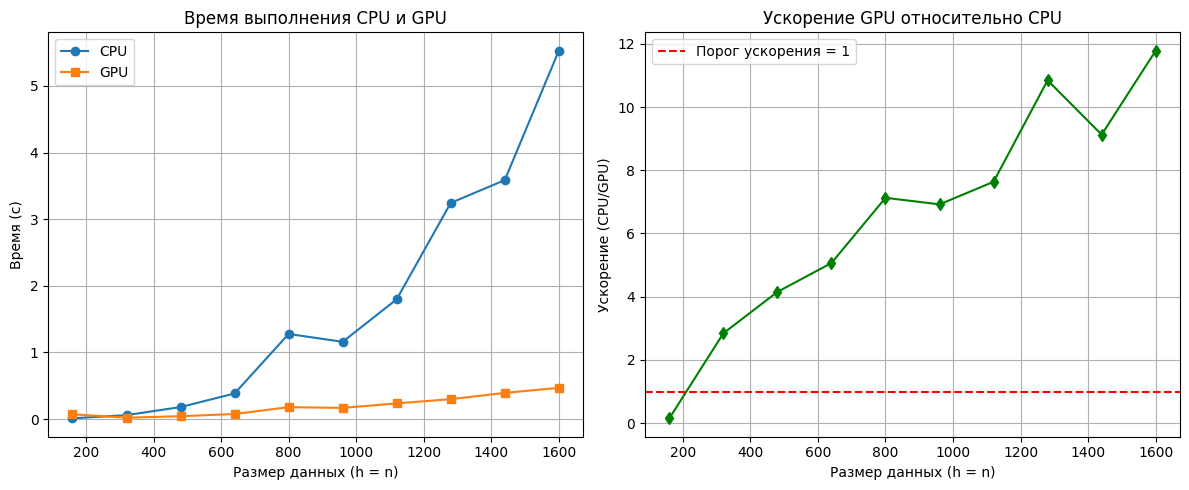

In [27]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(df['Размер (h=n)'], df['Время CPU (с)'], 'o-', label='CPU')
plt.plot(df['Размер (h=n)'], df['Время GPU (с)'], 's-', label='GPU')
plt.xlabel('Размер данных (h = n)')
plt.ylabel('Время (с)')
plt.title('Время выполнения CPU и GPU')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(df['Размер (h=n)'], df['Ускорение'], 'd-', color='green')
plt.xlabel('Размер данных (h = n)')
plt.ylabel('Ускорение (CPU/GPU)')
plt.title('Ускорение GPU относительно CPU')
plt.axhline(y=1, color='r', linestyle='--', label='Порог ускорения = 1')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Cохранение данных в txt:

In [28]:
def save_input_data_txt(filename, H, substrings):
    """Сохраняет H и подстроки в текстовый файл."""
    with open(filename, 'w') as f:
        f.write(f"{len(H)}\n")
        f.write(' '.join(str(b) for b in H) + "\n")
        f.write(f"{len(substrings)}\n")
        for s in substrings:
            f.write(f"{len(s)}\n")
            f.write(' '.join(str(b) for b in s) + "\n")

def load_input_data_txt(filename):
    """Загружает H и подстроки из текстового файла."""
    with open(filename, 'r') as f:
        lines = [line.strip() for line in f if line.strip()]
    idx = 0
    h = int(lines[idx]); idx += 1
    H = np.array([int(x) for x in lines[idx].split()], dtype=np.uint8); idx += 1
    n_sub = int(lines[idx]); idx += 1
    substrings = []
    for _ in range(n_sub):
        length = int(lines[idx]); idx += 1
        s = np.array([int(x) for x in lines[idx].split()], dtype=np.uint8); idx += 1
        substrings.append(s)
    return H, substrings

Программа для варианта ручного ввода данных:

In [29]:
print("=== Массовый поиск подстрок (CPU/GPU) ===\n")

h = int(input("Длина буфера H: "))
n_sub = int(input("Количество подстрок: "))
min_len = int(input("Минимальная длина подстроки: "))
max_len = int(input("Максимальная длина подстроки: "))
mode = input("Режим поиска (1 - только факт присутствия, 2 - все позиции): ").strip()
return_positions = (mode == '2')

print("\nГенерация случайных данных...")
H, substrings = generate_data(h, n_sub, min_len, max_len, seed=42)

filename = "input_data.txt"
save_input_data_txt(filename, H, substrings)
print(f"Входные данные сохранены в файл: {filename}")

start_cpu = time.perf_counter()
res_cpu = mass_search_CPU(H, substrings, return_positions=return_positions)
cpu_time = time.perf_counter() - start_cpu

start_gpu = time.perf_counter()
res_gpu = mass_search_GPU(H, substrings, return_positions=return_positions)
gpu_time = time.perf_counter() - start_gpu

match = (set(res_cpu) == set(res_gpu))

print(f"Время CPU: {cpu_time:.6f} с")
print(f"Время GPU: {gpu_time:.6f} с")
print(f"Ускорение: {cpu_time / gpu_time:.2f}x")
print(f"Результаты совпадают: {'ДА' if match else 'НЕТ'}")

print("\nРезультаты поиска:")
if return_positions:
  print(f"Найдено вхождений: {len(res_cpu)}")
  if len(res_cpu) <= 50:
    print("(номер_подстроки, позиция_начала):", res_cpu)
  else:
    print("(номер_подстроки, позиция_начала): слишком много для вывода")
else:
  print(f"Найдены подстроки с номерами: {res_cpu}")

  if not match:
    print("\nВНИМАНИЕ: результаты CPU и GPU различаются!")
    diff_cpu = set(res_cpu) - set(res_gpu)
    diff_gpu = set(res_gpu) - set(res_cpu)
    if diff_cpu:
        print(f"Только в CPU: {diff_cpu}")
    if diff_gpu:
        print(f"Только в GPU: {diff_gpu}")

=== Массовый поиск подстрок (CPU/GPU) ===

Длина буфера H: 1000
Количество подстрок: 5
Минимальная длина подстроки: 5
Максимальная длина подстроки: 8
Режим поиска (1 - только факт присутствия, 2 - все позиции): 1

Генерация случайных данных...
Входные данные сохранены в файл: input_data.txt
Время CPU: 0.007216 с
Время GPU: 0.003619 с
Ускорение: 1.99x
Результаты совпадают: ДА

Результаты поиска:
Найдены подстроки с номерами: []


/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 63 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))
